# decision_harness_lab — a generic Bayesian decision harness, and does outcome *shape* carry information a scalar EV hides?

Generalizes `../decision.py`'s Skip/Probe/Drill core (3 actions x 2 states) to an arbitrary array of
actions, costs, and outcome distributions, adds a Monte Carlo simulation layer (`harness.py`), and
asks a question none of this codebase's prior decision labs visualized directly: **does the *shape*
of an action's simulated outcome distribution — not just its mean — carry information worth looking
at?** Three toy examples, each engineered to produce a different shape (multi-lump, bimodal, skewed),
sanity-checked against `decision.py`'s closed-form `expected_value_nstate`/`bayes_action_nstate` so
the Monte Carlo layer is never trusted blindly.

**No GP / soft-EM anywhere in this lab.** This is Phase 0-2 only — the generic harness on synthetic
toy data. See `LAB_PLAN.md`'s "Risks" section for why a real, recurring, GP-soft-EM-backed
application is a separate, later lab, not a next cell in this notebook.

> Every number below is computed live in this notebook, not retyped from `LAB_PLAN.md`.

In [1]:
import os
import sys

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.join(os.getcwd(), "toy_examples"))

from harness import simulate, summarize, check_against_closed_form
import viz

viz.apply_house_style(plt)
rng = np.random.default_rng(0)
N_DRAWS = 200_000
print(f"n_draws={N_DRAWS}")

n_draws=200000


## Toy example 1 — newsvendor (order-quantity under uncertain demand)

Three imbalanced demand states (low 50% / medium 35% / high 15%), three order-quantity actions.
Demand is deterministic *within* a state (the closed-form `V` matrix below is exact); the only
randomness is small independent noise on the realized price/cost. Expect a distinctly multi-lumped
histogram per action — the shape comes from the discrete demand states themselves, not smooth noise.

closed-form cross-check ok=True
       order_low: monte_carlo= +150.08  closed_form= +150.00
    order_medium: monte_carlo= +224.51  closed_form= +225.00
      order_high: monte_carlo= +183.58  closed_form= +184.50
  best action -- monte_carlo='order_medium'  closed_form='order_medium'


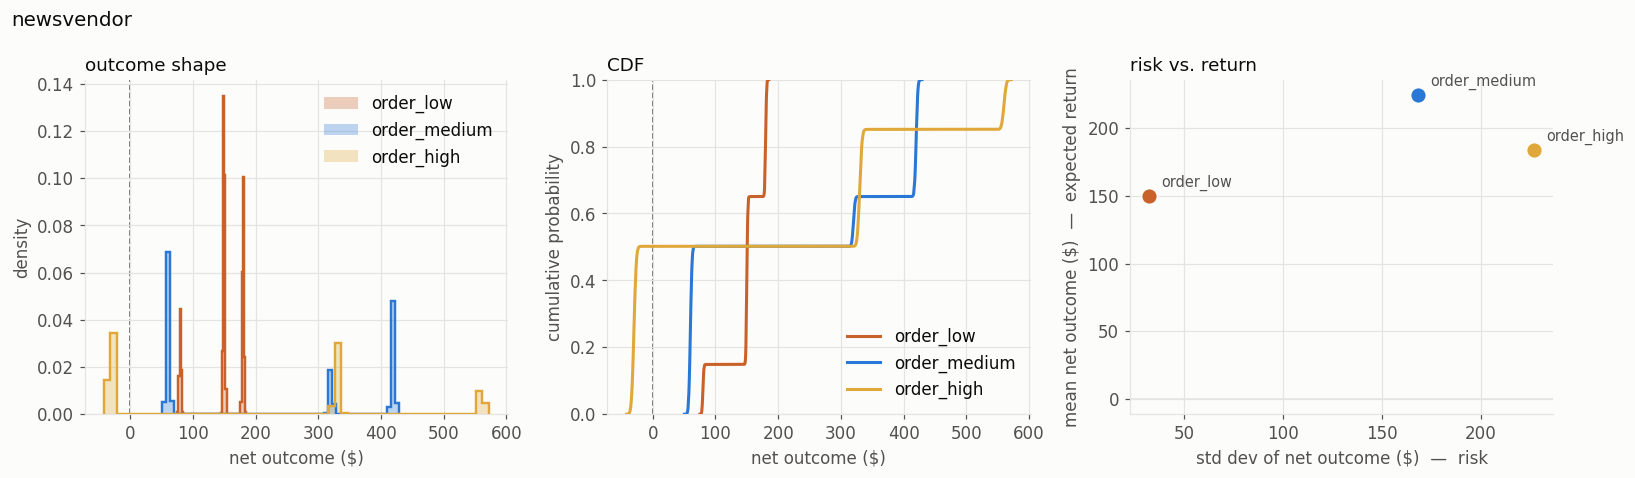

| action | mean | std | p5 | p50 | p95 | P(loss) | CVaR 5% |
|---|---|---|---|---|---|---|---|
| order_low | 150 | 32 | 79 | 151 | 181 | 0.0% | 79 |
| order_medium | 225 | 168 | 57 | 66 | 422 | 0.0% | 56 |
| order_high | 184 | 227 | -34 | -22 | 561 | 50.2% | -35 |


In [2]:
import newsvendor

decision = newsvendor.build_decision()
samples, state_idx = simulate(decision, n_draws=N_DRAWS, rng=rng)
summary = summarize(samples)
ok, report = check_against_closed_form(decision, summary)
print(f"closed-form cross-check ok={ok}")
for name in decision.action_names:
    r = report[name]
    print(f"  {name:>14}: monte_carlo={r['monte_carlo']:+8.2f}  closed_form={r['closed_form']:+8.2f}")
print(f"  best action -- monte_carlo={report['best_action']['monte_carlo']!r}  "
      f"closed_form={report['best_action']['closed_form']!r}")
assert ok

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
viz.plot_outcome_distributions(samples, axes[0], title="outcome shape")
viz.plot_outcome_cdf(samples, axes[1], title="CDF")
viz.plot_risk_return(summary, axes[2], title="risk vs. return")
fig.suptitle("newsvendor", x=0.01, ha="left", fontsize=13, color=viz.INK)
fig.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown(viz.summary_markdown_table(summary)))

## Toy example 2 — buy insurance vs. self-insure (the flagship "shape matters" example)

A rare, imbalanced state split (92% no-disaster / 8% disaster — deliberately the same shape of
regime this codebase's own GP soft-EM litmus test (`../PLAN.md` section 7) requires before that
mechanism is worth its complexity). `self_insure`'s outcome distribution is genuinely **bimodal**: a
tight cluster near \$0 (nothing happened) and a separated cluster near -\$200k (catastrophic loss) —
a single expected-value number completely hides this. `buy_insurance` wins on raw expected value
here, but the charts below show *why* that comparison undersells the risk `self_insure` is quietly
carrying. The distribution/CDF panels use a symlog x-axis (linear near 0, log further out) — without
it, the near-\$0 cluster is invisible next to the -\$200k tail on a linear scale.

closed-form cross-check ok=True
   buy_insurance: monte_carlo=  -5080.72  closed_form=  -5080.00
     self_insure: monte_carlo= -16168.47  closed_form= -16000.00
  best action (by mean) -- monte_carlo='buy_insurance'  closed_form='buy_insurance'


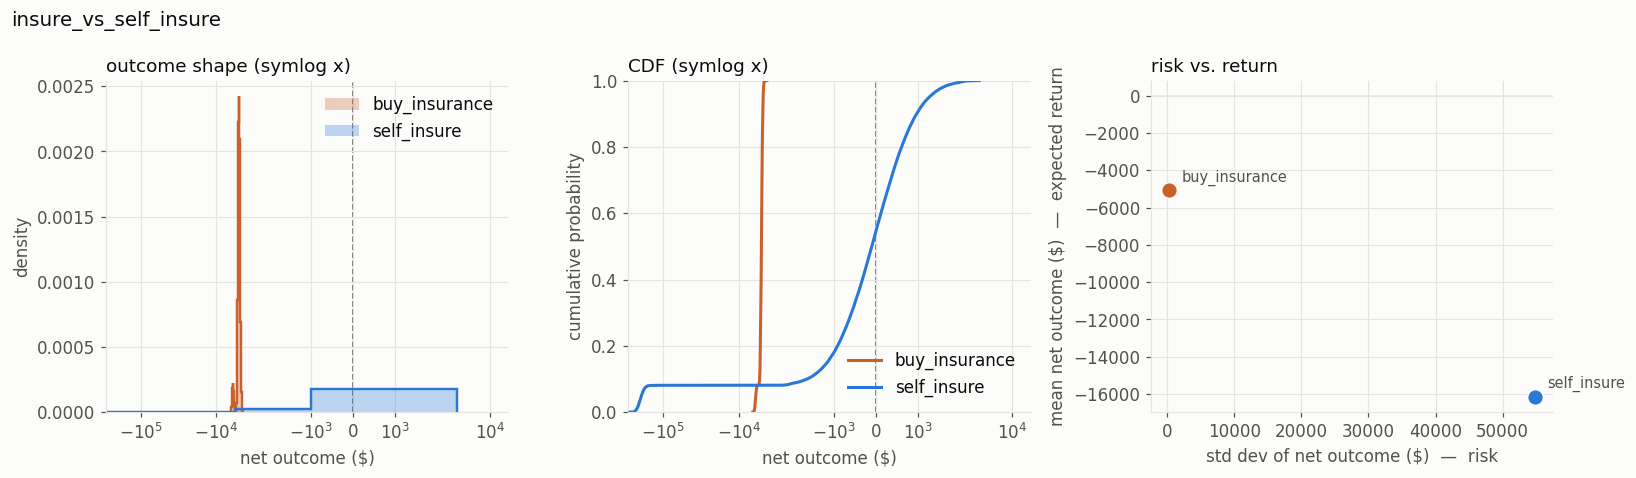

| action | mean | std | p5 | p50 | p95 | P(loss) | CVaR 5% |
|---|---|---|---|---|---|---|---|
| buy_insurance | -5,081 | 311 | -5,956 | -5,016 | -4,759 | 100.0% | -6,092 |
| self_insure | -16,168 | 54,831 | -194,111 | -89 | 1,277 | 54.1% | -212,386 |


**Read together, not the mean alone**: `buy_insurance` wins on expected value (-5,081 vs -16,168), but `self_insure`'s CVaR-5% (-212,386) and P(loss) (54%) show a risk profile the mean comparison alone never surfaces — the CDF's two-plateau shape is the visual fingerprint of the underlying rare/imbalanced regime, not noise.

In [3]:
import insure_vs_self_insure

decision = insure_vs_self_insure.build_decision()
samples, state_idx = simulate(decision, n_draws=N_DRAWS, rng=rng)
summary = summarize(samples)
ok, report = check_against_closed_form(decision, summary)
print(f"closed-form cross-check ok={ok}")
for name in decision.action_names:
    r = report[name]
    print(f"  {name:>14}: monte_carlo={r['monte_carlo']:+10.2f}  closed_form={r['closed_form']:+10.2f}")
print(f"  best action (by mean) -- monte_carlo={report['best_action']['monte_carlo']!r}  "
      f"closed_form={report['best_action']['closed_form']!r}")
assert ok

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
viz.plot_outcome_distributions(samples, axes[0], title="outcome shape (symlog x)",
                                xscale="symlog", linthresh=2_000)
viz.plot_outcome_cdf(samples, axes[1], title="CDF (symlog x)", xscale="symlog", linthresh=2_000)
viz.plot_risk_return(summary, axes[2], title="risk vs. return")
fig.suptitle("insure_vs_self_insure", x=0.01, ha="left", fontsize=13, color=viz.INK)
fig.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown(viz.summary_markdown_table(summary)))
display(Markdown(
    f"**Read together, not the mean alone**: `buy_insurance` wins on expected value "
    f"({summary['buy_insurance']['mean']:,.0f} vs {summary['self_insure']['mean']:,.0f}), but "
    f"`self_insure`'s CVaR-5% ({summary['self_insure']['cvar5']:,.0f}) and "
    f"P(loss) ({summary['self_insure']['prob_loss']:.0%}) show a risk profile the mean comparison "
    f"alone never surfaces — the CDF's two-plateau shape is the visual fingerprint of the "
    f"underlying rare/imbalanced regime, not noise."
))

## Toy example 3 — conservative vs. aggressive investment allocation

A roughly balanced state split (45% bear / 55% bull — deliberately *not* rare/imbalanced, unlike
example 2, for contrast). `conservative`'s outcome is a near-symmetric Gaussian; `aggressive`'s is
right-skewed in the bull state (lognormal-shaped upside) with a real loss in the bear state — a
third, distinct shape. `aggressive` wins on raw expected value despite the extra risk; the point of
this example is to show that side by side with its shape, not to argue one choice is correct.

closed-form cross-check ok=True
    conservative: monte_carlo= +2551.20  closed_form= +2550.00
      aggressive: monte_carlo= +3158.43  closed_form= +3150.00
  best action -- monte_carlo='aggressive'  closed_form='aggressive'


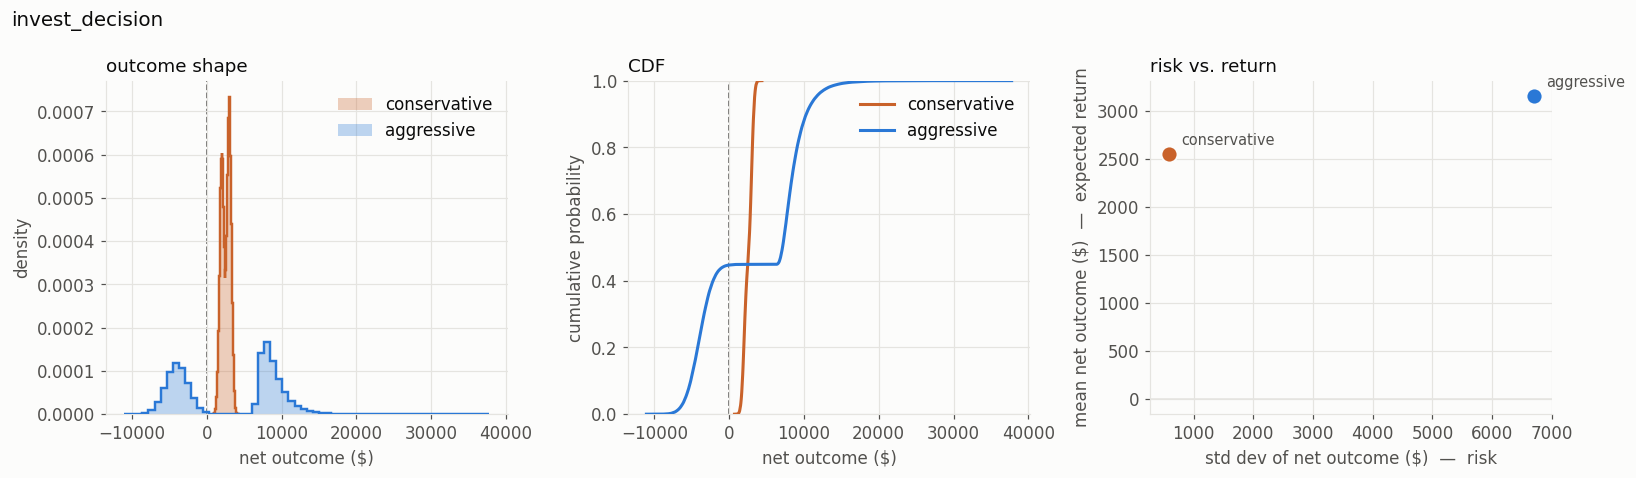

| action | mean | std | p5 | p50 | p95 | P(loss) | CVaR 5% |
|---|---|---|---|---|---|---|---|
| conservative | 2,551 | 582 | 1,632 | 2,629 | 3,402 | 0.0% | 1,488 |
| aggressive | 3,158 | 6,699 | -5,824 | 7,131 | 11,575 | 44.7% | -6,552 |


In [4]:
import invest_decision

decision = invest_decision.build_decision()
samples, state_idx = simulate(decision, n_draws=N_DRAWS, rng=rng)
summary = summarize(samples)
ok, report = check_against_closed_form(decision, summary)
print(f"closed-form cross-check ok={ok}")
for name in decision.action_names:
    r = report[name]
    print(f"  {name:>14}: monte_carlo={r['monte_carlo']:+9.2f}  closed_form={r['closed_form']:+9.2f}")
print(f"  best action -- monte_carlo={report['best_action']['monte_carlo']!r}  "
      f"closed_form={report['best_action']['closed_form']!r}")
assert ok

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
viz.plot_outcome_distributions(samples, axes[0], title="outcome shape")
viz.plot_outcome_cdf(samples, axes[1], title="CDF")
viz.plot_risk_return(summary, axes[2], title="risk vs. return")
fig.suptitle("invest_decision", x=0.01, ha="left", fontsize=13, color=viz.INK)
fig.tight_layout()
plt.show()

from IPython.display import Markdown, display
display(Markdown(viz.summary_markdown_table(summary)))

## Takeaway

Three toy examples, three genuinely different outcome shapes (multi-lump, bimodal, right-skewed),
all reproduced from a single generic `Decision`/`Action`/`simulate`/`summarize` API sitting on top of
the shared `decision.py` core — and all three Monte Carlo means matched `decision.py`'s closed-form
`expected_value_nstate` within tolerance, so the simulation layer is verified, not just plausible.

**Next, per `LAB_PLAN.md`'s explicit scope boundary**: this notebook stays on synthetic toy data.
Before any GP soft-EM work touches this harness, a real recurring decision domain needs to be chosen
and checked against `../PLAN.md` section 7's two-condition litmus test (regime recurs many times,
regime is rare/imbalanced) — exactly the discipline that already separated this codebase's convincing
soft-EM results from its null ones.